# День 08. Упражнение 05
# Кластеризация

## 0. Импорты

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage


## 1. Предобработка

1. Прочитай файл [`regression.csv`](https://drive.google.com/file/d/1fzOPkuXoxLleOsvNVCT0m-LKxlid33ma/view?usp=sharing) в DataFrame.
2. Удали колонку `pageviews`, мы будем кластеризовать пользователей только по количеству коммитов и их средней разнице.

In [2]:
df = pd.read_csv('../../src/data/regression.csv')


In [3]:
X = df.drop(columns=['uid', 'pageviews']).values


## 2. KMeans

1. Ознакомься с документацией и разберись, как работает этот алгоритм.
2. Используй этот алгоритм для создания кластеров с параметрами `random_state=21` и `n_clusters=3`.
3. Визуализируй данные на `scatter plot`.
4. Попробуй разные значения `n_clusters` и посмотри, как изменится твой график.
5. Вычисли `silhouette_score` (см. документацию по метрике).

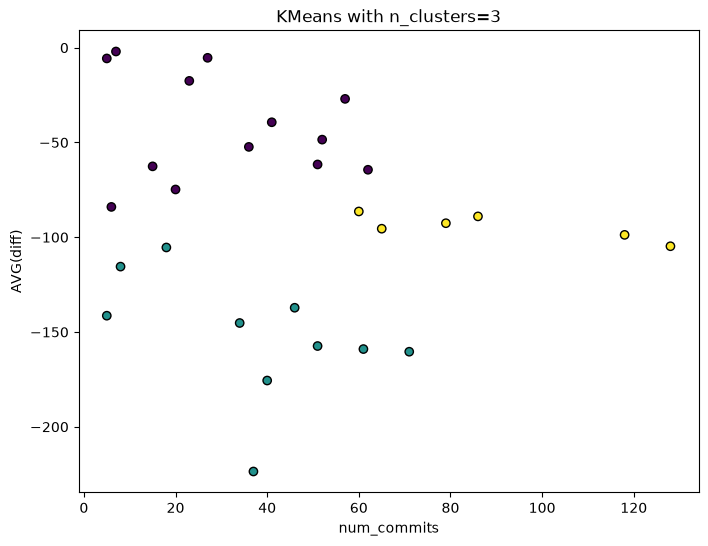

In [4]:
km = KMeans(n_clusters=3, random_state=21, n_init='auto')
labels = km.fit_predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k')
plt.xlabel('num_commits')
plt.ylabel('AVG(diff)')
plt.title('KMeans with n_clusters=3')
plt.show()


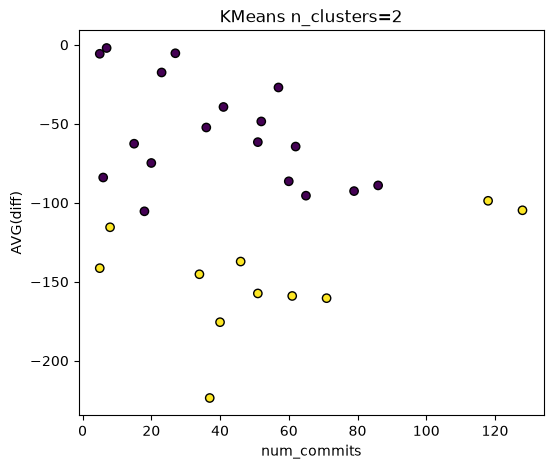

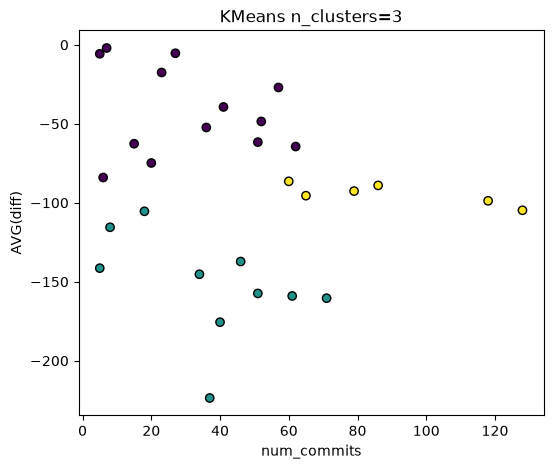

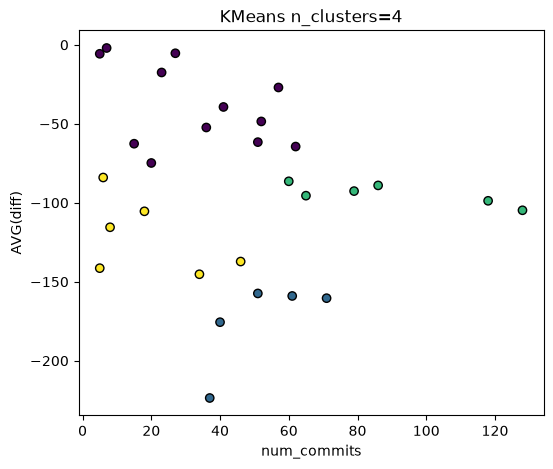

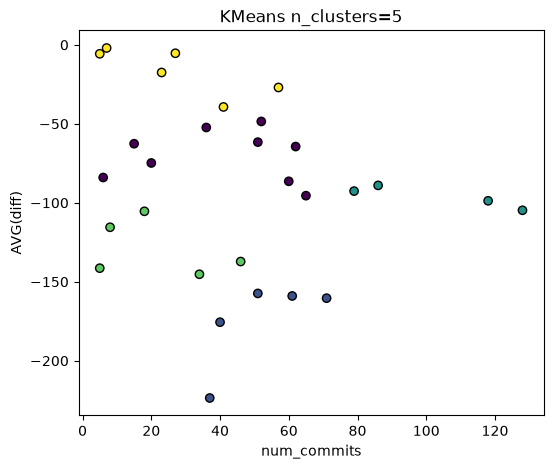

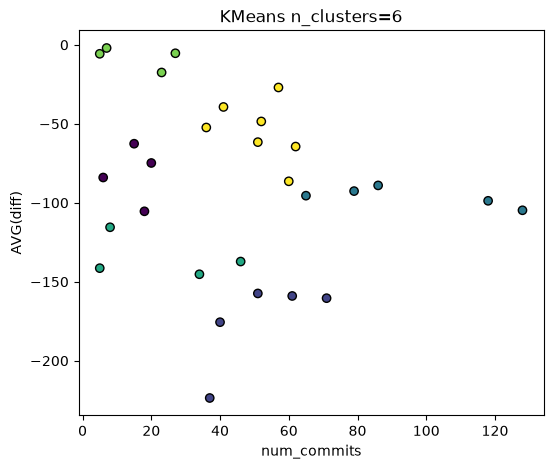

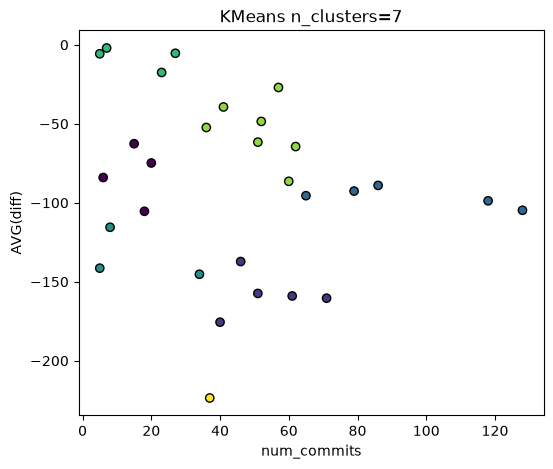

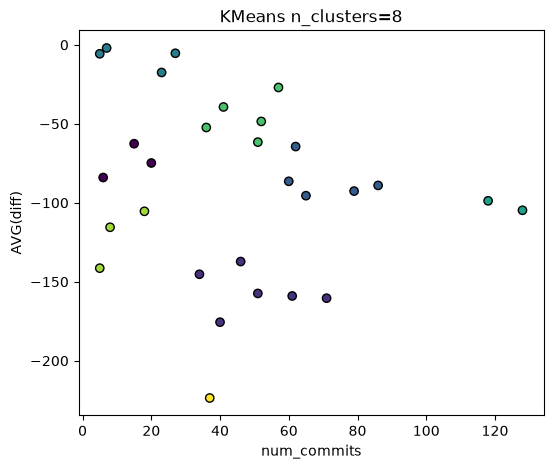

In [5]:
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=21, n_init='auto')
    labels = km.fit_predict(X)
    plt.figure(figsize=(6, 5))
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k')
    plt.xlabel('num_commits')
    plt.ylabel('AVG(diff)')
    plt.title(f'KMeans n_clusters={k}')
    plt.show()


In [6]:
km = KMeans(n_clusters=3, random_state=21, n_init='auto')
labels = km.fit_predict(X)
print(f'silhouette_score = {silhouette_score(X, labels):.4f}')


silhouette_score = 0.4454


In [7]:
best_k = 2
best_s = -1
for k in range(2, 15):
    km = KMeans(n_clusters=k, random_state=21, n_init='auto')
    labels = km.fit_predict(X)
    s = silhouette_score(X, labels)
    print(f'n_clusters={k}: silhouette={s:.4f}')
    if s > best_s:
        best_s = s
        best_k = k
print(f'\nBest n_clusters = {best_k} ({best_s:.4f})')


n_clusters=2: silhouette=0.4195
n_clusters=3: silhouette=0.4454
n_clusters=4: silhouette=0.4150
n_clusters=5: silhouette=0.3521
n_clusters=6: silhouette=0.3954
n_clusters=7: silhouette=0.3964
n_clusters=8: silhouette=0.4864
n_clusters=9: silhouette=0.4538
n_clusters=10: silhouette=0.4263
n_clusters=11: silhouette=0.3813
n_clusters=12: silhouette=0.3818
n_clusters=13: silhouette=0.3870
n_clusters=14: silhouette=0.3876

Best n_clusters = 8 (0.4864)


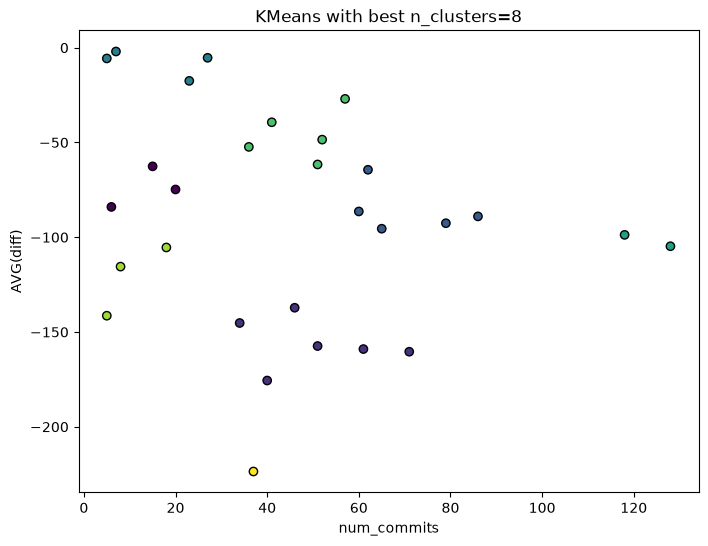

In [8]:
km = KMeans(n_clusters=best_k, random_state=21, n_init='auto')
best_labels = km.fit_predict(X)
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=best_labels, cmap='viridis', edgecolors='k')
plt.xlabel('num_commits')
plt.ylabel('AVG(diff)')
plt.title(f'KMeans with best n_clusters={best_k}')
plt.show()


## 3. DBSCAN

1. Ознакомься с документацией и разберись, как работает этот алгоритм.
2. Используй этот алгоритм для создания кластеров с параметрами `eps=20` и `min_samples=2`.
3. Визуализируй данные на `scatter plot`.
4. Попробуй разные значения `eps` и `min_samples` и посмотри, как изменится твой график.
5. Вычисли `silhouette_score` (см. документацию по метрике).

Number of clusters found: 9


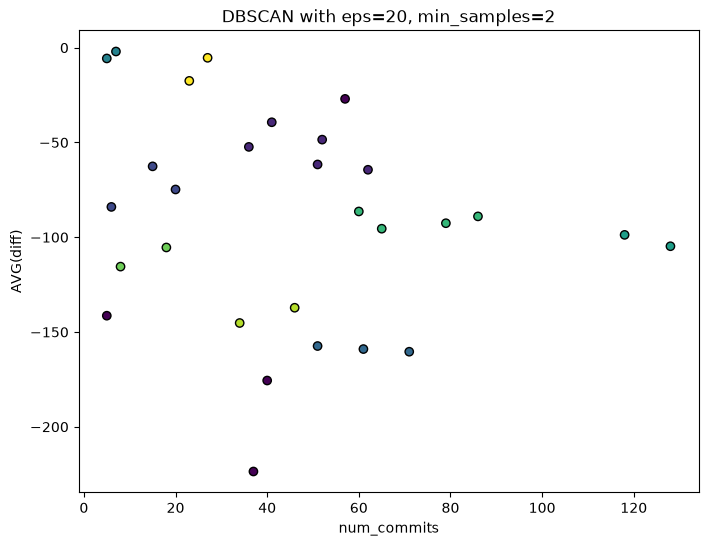

In [9]:
db = DBSCAN(eps=20, min_samples=2)
labels = db.fit_predict(X)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f'Number of clusters found: {n_clusters}')

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k')
plt.xlabel('num_commits')
plt.ylabel('AVG(diff)')
plt.title('DBSCAN with eps=20, min_samples=2')
plt.show()


eps=5: only 1 cluster(s)
eps=10: clusters=2, silhouette=-0.0792


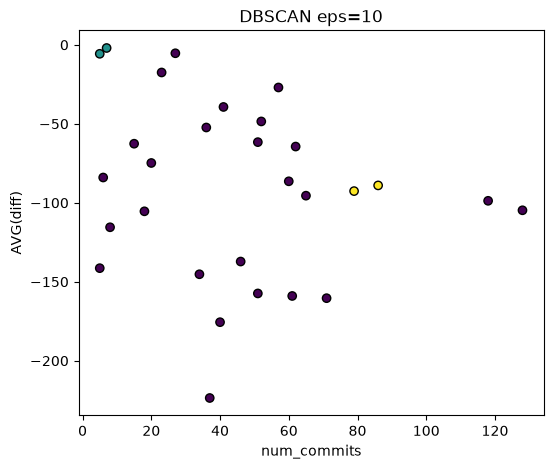

eps=15: clusters=9, silhouette=0.3470


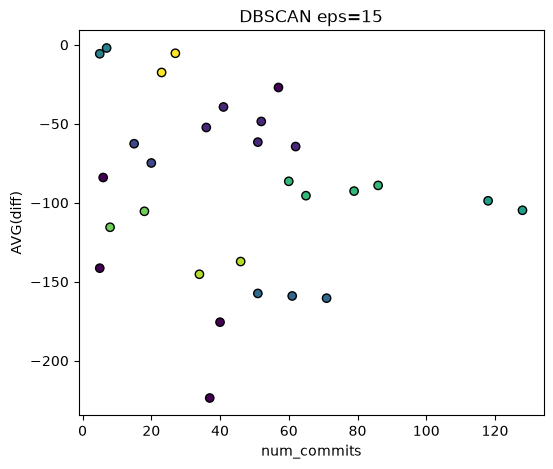

eps=20: clusters=9, silhouette=0.3834


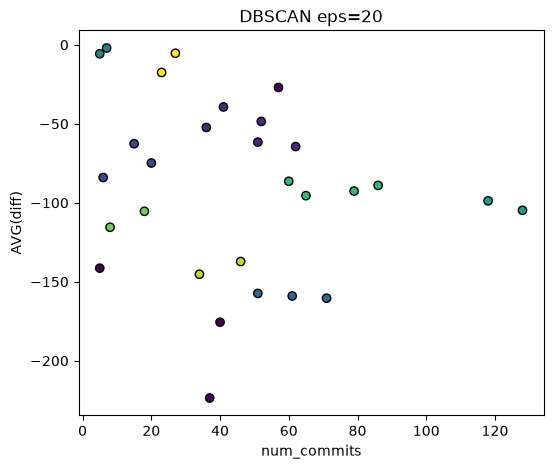

eps=25: clusters=4, silhouette=0.3439


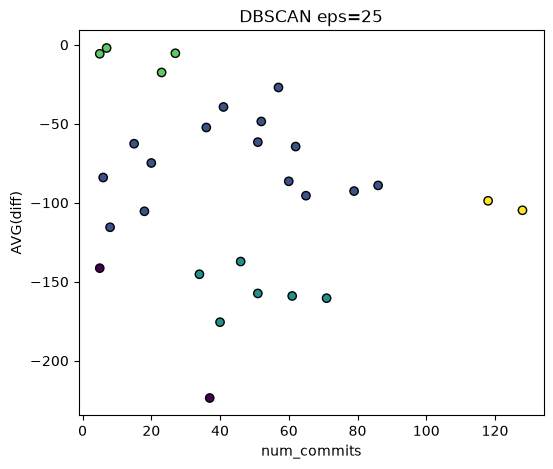

In [10]:
for eps in range(5, 30, 5):
    db = DBSCAN(eps=eps, min_samples=2)
    labels = db.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters > 1:
        s = silhouette_score(X, labels)
        print(f'eps={eps}: clusters={n_clusters}, silhouette={s:.4f}')
        plt.figure(figsize=(6, 5))
        plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k')
        plt.xlabel('num_commits')
        plt.ylabel('AVG(diff)')
        plt.title(f'DBSCAN eps={eps}')
        plt.show()
    else:
        print(f'eps={eps}: only {n_clusters} cluster(s)')


min_samples=1: clusters=13, silhouette=0.4322


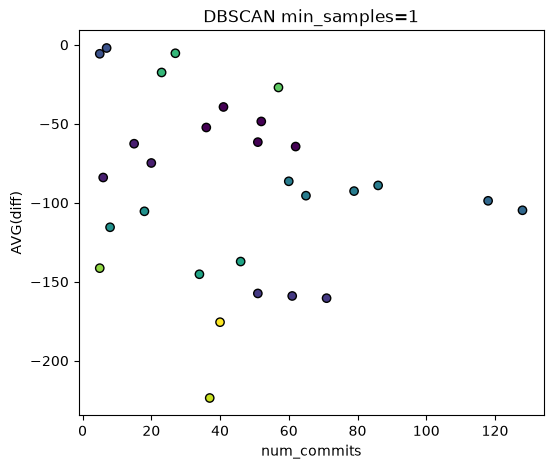

min_samples=2: clusters=9, silhouette=0.3834


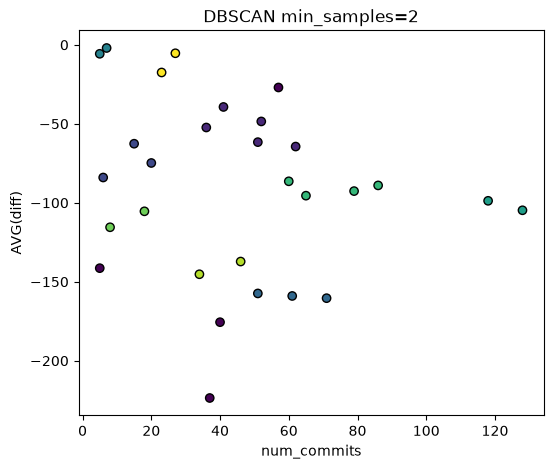

min_samples=3: clusters=4, silhouette=0.0467


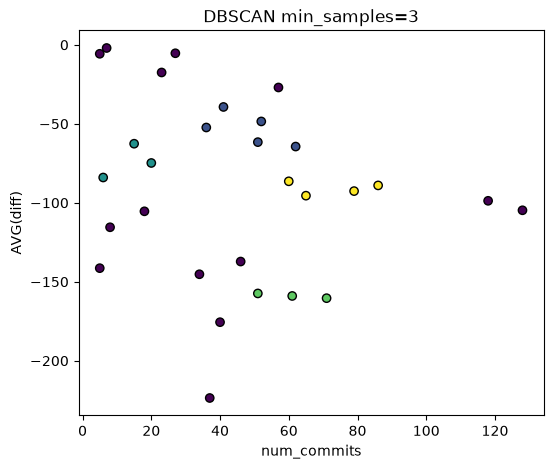

min_samples=4: clusters=2, silhouette=-0.0273


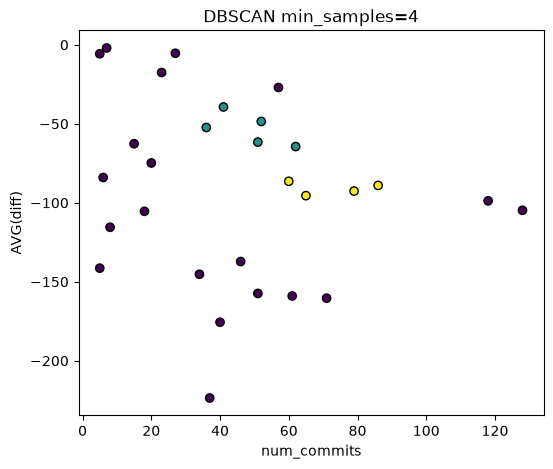

min_samples=5: only 1 cluster(s)


In [11]:
for ms in range(1, 6):
    db = DBSCAN(eps=20, min_samples=ms)
    labels = db.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters > 1:
        s = silhouette_score(X, labels)
        print(f'min_samples={ms}: clusters={n_clusters}, silhouette={s:.4f}')
        plt.figure(figsize=(6, 5))
        plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k')
        plt.xlabel('num_commits')
        plt.ylabel('AVG(diff)')
        plt.title(f'DBSCAN min_samples={ms}')
        plt.show()
    else:
        print(f'min_samples={ms}: only {n_clusters} cluster(s)')


In [12]:
db = DBSCAN(eps=20, min_samples=2)
labels = db.fit_predict(X)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
if n_clusters > 1:
    print(f'silhouette_score = {silhouette_score(X, labels):.4f}')
else:
    print('Not enough clusters for silhouette_score')


silhouette_score = 0.3834


In [13]:
best_eps = 0
best_s = -1
for eps in range(5, 40):
    db = DBSCAN(eps=eps, min_samples=2)
    labels = db.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters > 1:
        s = silhouette_score(X, labels)
        print(f'eps={eps}: silhouette={s:.4f}')
        if s > best_s:
            best_s = s
            best_eps = eps
print(f'\nBest eps = {best_eps} ({best_s:.4f})')


eps=8: silhouette=-0.0792
eps=9: silhouette=-0.0792
eps=10: silhouette=-0.0792
eps=11: silhouette=-0.0746
eps=12: silhouette=0.0459
eps=13: silhouette=0.1287
eps=14: silhouette=0.2520
eps=15: silhouette=0.3470
eps=16: silhouette=0.3470
eps=17: silhouette=0.3834
eps=18: silhouette=0.3834
eps=19: silhouette=0.3834
eps=20: silhouette=0.3834
eps=21: silhouette=0.4646
eps=22: silhouette=0.4794
eps=23: silhouette=0.3875
eps=24: silhouette=0.3373
eps=25: silhouette=0.3439
eps=26: silhouette=0.3439
eps=27: silhouette=0.3425
eps=28: silhouette=0.3425
eps=29: silhouette=0.3591
eps=30: silhouette=0.1988
eps=31: silhouette=0.1988
eps=32: silhouette=0.1988
eps=33: silhouette=0.1988

Best eps = 22 (0.4794)


In [14]:
best_ms = 0
best_s = -1
for ms in range(1, 6):
    db = DBSCAN(eps=best_eps, min_samples=ms)
    labels = db.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters > 1:
        s = silhouette_score(X, labels)
        print(f'min_samples={ms}: silhouette={s:.4f}')
        if s > best_s:
            best_s = s
            best_ms = ms
print(f'\nBest min_samples = {best_ms} ({best_s:.4f})')


min_samples=1: silhouette=0.4871
min_samples=2: silhouette=0.4794
min_samples=3: silhouette=0.3596
min_samples=4: silhouette=0.1456
min_samples=5: silhouette=0.0580

Best min_samples = 1 (0.4871)


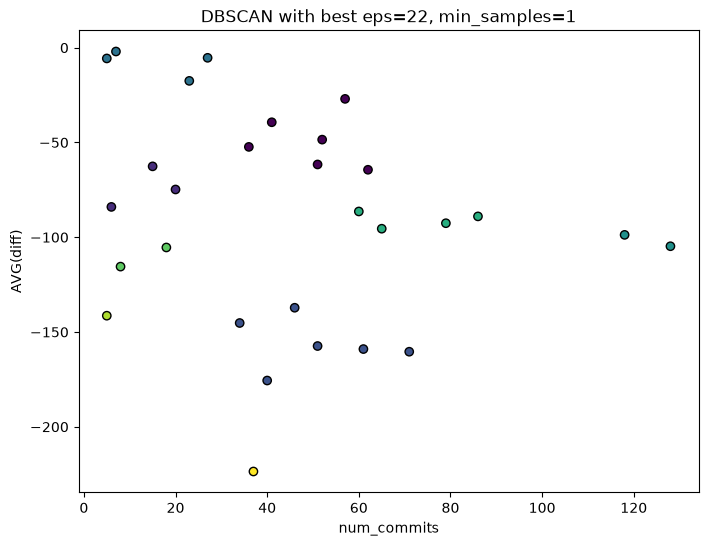

In [15]:
db = DBSCAN(eps=best_eps, min_samples=best_ms)
best_labels = db.fit_predict(X)
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=best_labels, cmap='viridis', edgecolors='k')
plt.xlabel('num_commits')
plt.ylabel('AVG(diff)')
plt.title(f'DBSCAN with best eps={best_eps}, min_samples={best_ms}')
plt.show()


## 4. Иерархическая кластеризация (AgglomerativeClustering)

1. Используй этот алгоритм для создания кластеров с параметром `n_clusters=5`.
2. Визуализируй данные на `scatter plot`.
3. Попробуй разные значения `n_clusters` и посмотри, как изменится твой график.
4. Вычисли `silhouette_score`.
5. Визуализируй `dendrogram`.

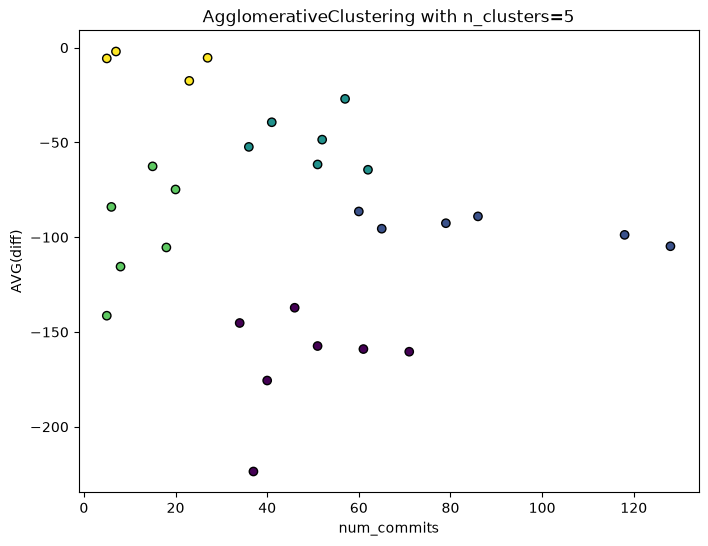

In [16]:
ag = AgglomerativeClustering(n_clusters=5)
labels = ag.fit_predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k')
plt.xlabel('num_commits')
plt.ylabel('AVG(diff)')
plt.title('AgglomerativeClustering with n_clusters=5')
plt.show()


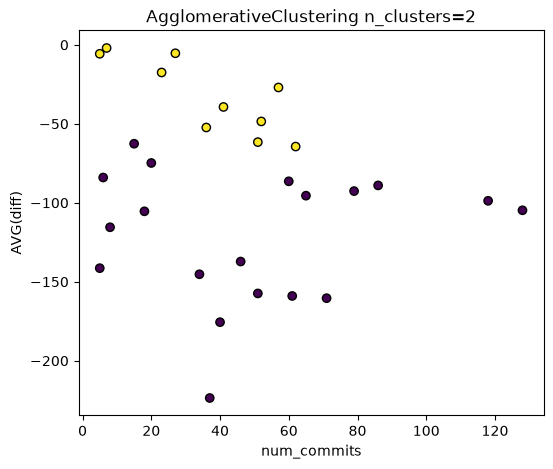

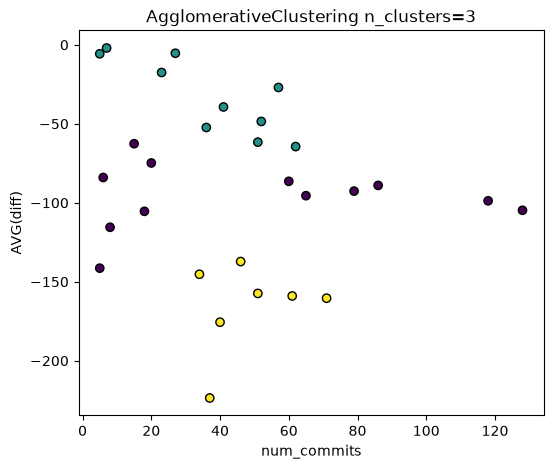

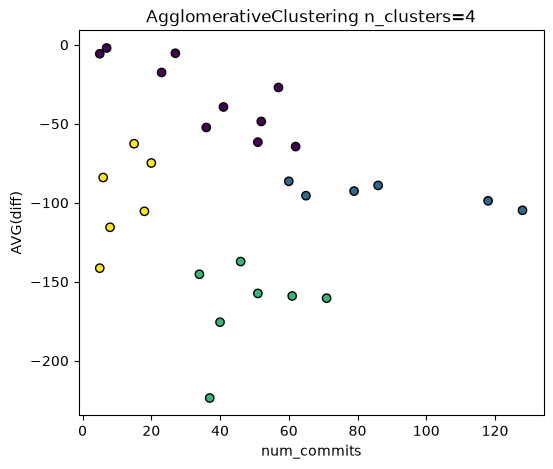

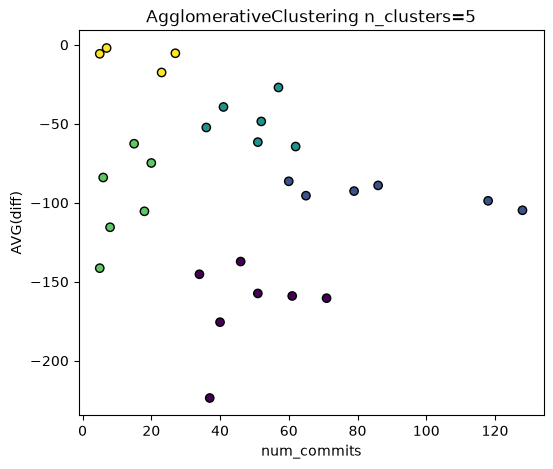

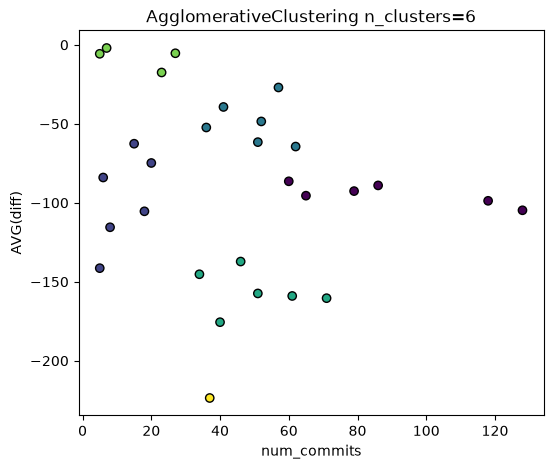

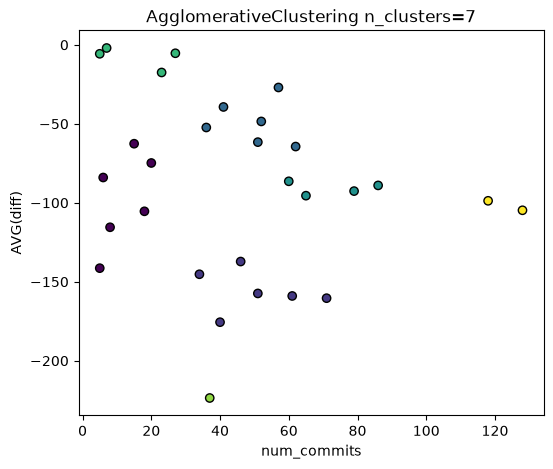

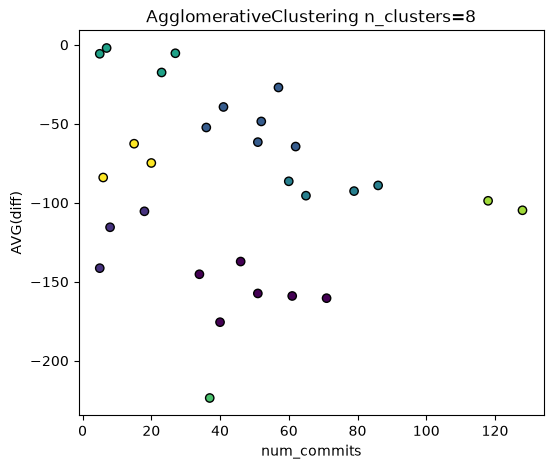

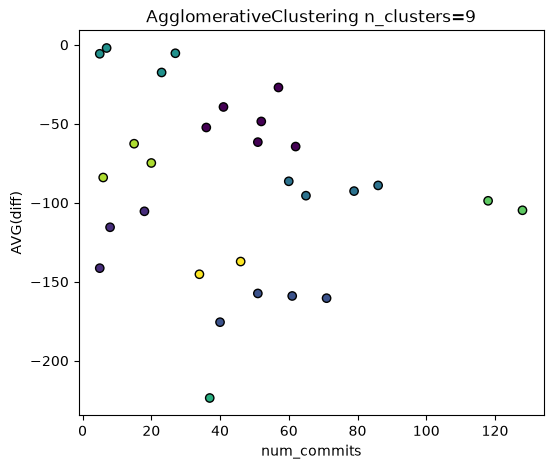

In [17]:
for k in range(2, 10):
    ag = AgglomerativeClustering(n_clusters=k)
    labels = ag.fit_predict(X)
    plt.figure(figsize=(6, 5))
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k')
    plt.xlabel('num_commits')
    plt.ylabel('AVG(diff)')
    plt.title(f'AgglomerativeClustering n_clusters={k}')
    plt.show()


In [18]:
ag = AgglomerativeClustering(n_clusters=5)
labels = ag.fit_predict(X)
print(f'silhouette_score = {silhouette_score(X, labels):.4f}')


silhouette_score = 0.4638


In [19]:
best_k_ag = 2
best_s_ag = -1
for k in range(2, 15):
    ag = AgglomerativeClustering(n_clusters=k)
    labels = ag.fit_predict(X)
    s = silhouette_score(X, labels)
    print(f'n_clusters={k}: silhouette={s:.4f}')
    if s > best_s_ag:
        best_s_ag = s
        best_k_ag = k
print(f'\nBest n_clusters = {best_k_ag} ({best_s_ag:.4f})')


n_clusters=2: silhouette=0.3590
n_clusters=3: silhouette=0.3390
n_clusters=4: silhouette=0.4448
n_clusters=5: silhouette=0.4638
n_clusters=6: silhouette=0.4527
n_clusters=7: silhouette=0.4866
n_clusters=8: silhouette=0.5078
n_clusters=9: silhouette=0.4758
n_clusters=10: silhouette=0.4312
n_clusters=11: silhouette=0.4310
n_clusters=12: silhouette=0.4363
n_clusters=13: silhouette=0.4232
n_clusters=14: silhouette=0.4237

Best n_clusters = 8 (0.5078)


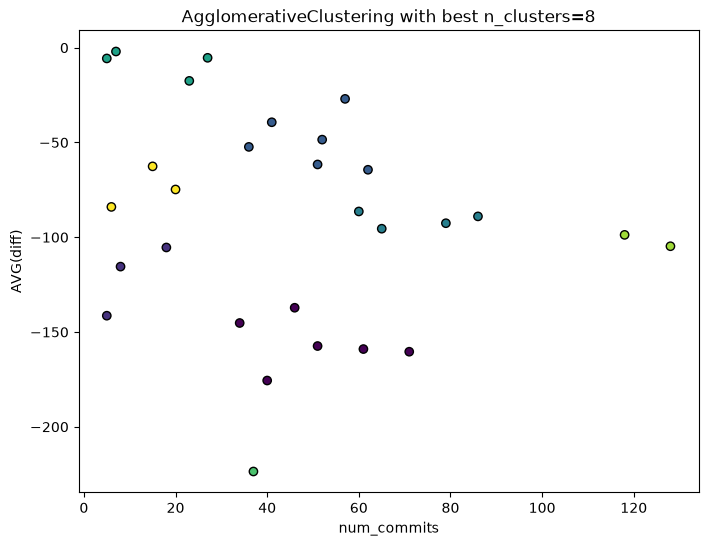

In [20]:
ag = AgglomerativeClustering(n_clusters=best_k_ag)
best_labels = ag.fit_predict(X)
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=best_labels, cmap='viridis', edgecolors='k')
plt.xlabel('num_commits')
plt.ylabel('AVG(diff)')
plt.title(f'AgglomerativeClustering with best n_clusters={best_k_ag}')
plt.show()


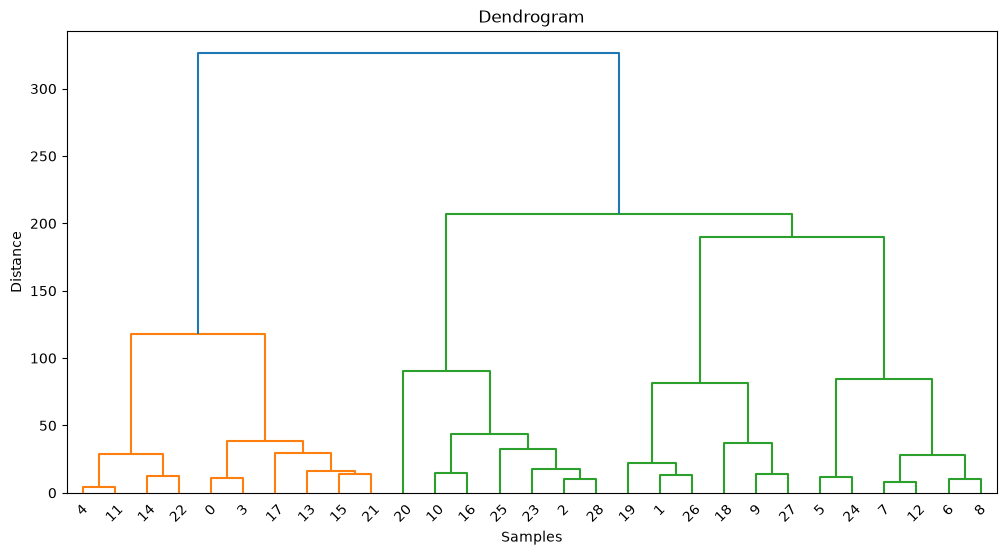

In [21]:
Z = linkage(X, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()


## 5. Функция

In [22]:
def cluster_optimize(model_class, model_params, param_name, param_range):
    scores = []
    best_param = None
    best_score = -1

    for val in param_range:
        params = model_params.copy()
        params[param_name] = val
        model = model_class(**params)
        labels = model.fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters > 1:
            s = silhouette_score(X, labels)
            scores.append((val, s))
            print(f'{param_name}={val}: silhouette={s:.4f}')
            if s > best_score:
                best_score = s
                best_param = val
        else:
            scores.append((val, -1))
            print(f'{param_name}={val}: only {n_clusters} cluster(s)')

    if best_param is None:
        best_param = param_range[0]
        best_score = 0

    print(f'\nBest {param_name} = {best_param} ({best_score:.4f})')

    params = model_params.copy()
    params[param_name] = best_param
    model = model_class(**params)
    best_labels = model.fit_predict(X)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    vals = [s[0] for s in scores]
    sc = [s[1] for s in scores]
    axes[0].plot(vals, sc, marker='o')
    axes[0].axvline(x=best_param, color='r', linestyle='--', alpha=0.5)
    axes[0].set_xlabel(param_name)
    axes[0].set_ylabel('silhouette_score')
    axes[0].set_title(f'silhouette_score vs {param_name}')
    axes[0].grid(True)

    axes[1].scatter(X[:, 0], X[:, 1], c=best_labels, cmap='viridis', edgecolors='k')
    axes[1].set_xlabel('num_commits')
    axes[1].set_ylabel('AVG(diff)')
    axes[1].set_title(f'{model_class.__name__} with best {param_name}={best_param}')

    plt.tight_layout()
    plt.show()
    return best_param


=== KMeans optimization ===
n_clusters=2: silhouette=0.4195
n_clusters=3: silhouette=0.4454
n_clusters=4: silhouette=0.4150
n_clusters=5: silhouette=0.3521
n_clusters=6: silhouette=0.3954
n_clusters=7: silhouette=0.3964
n_clusters=8: silhouette=0.4864
n_clusters=9: silhouette=0.4538
n_clusters=10: silhouette=0.4263
n_clusters=11: silhouette=0.3813
n_clusters=12: silhouette=0.3818
n_clusters=13: silhouette=0.3870
n_clusters=14: silhouette=0.3876

Best n_clusters = 8 (0.4864)


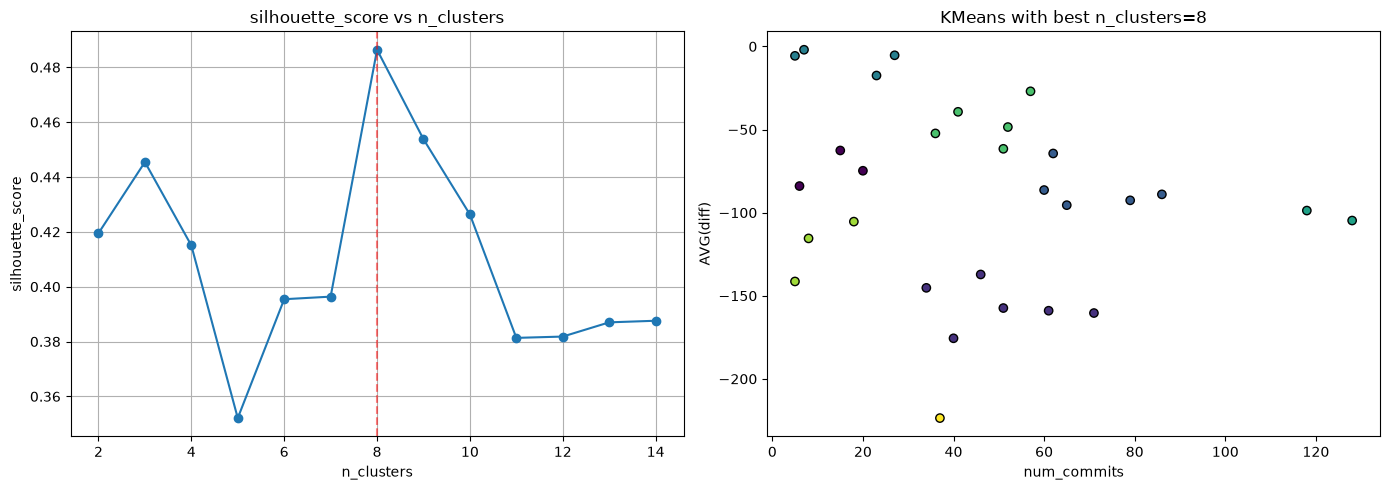


=== DBSCAN eps optimization ===
eps=5: only 1 cluster(s)
eps=6: only 1 cluster(s)
eps=7: only 1 cluster(s)
eps=8: silhouette=-0.0792
eps=9: silhouette=-0.0792
eps=10: silhouette=-0.0792
eps=11: silhouette=-0.0746
eps=12: silhouette=0.0459
eps=13: silhouette=0.1287
eps=14: silhouette=0.2520
eps=15: silhouette=0.3470
eps=16: silhouette=0.3470
eps=17: silhouette=0.3834
eps=18: silhouette=0.3834
eps=19: silhouette=0.3834
eps=20: silhouette=0.3834
eps=21: silhouette=0.4646
eps=22: silhouette=0.4794
eps=23: silhouette=0.3875
eps=24: silhouette=0.3373
eps=25: silhouette=0.3439
eps=26: silhouette=0.3439
eps=27: silhouette=0.3425
eps=28: silhouette=0.3425
eps=29: silhouette=0.3591
eps=30: silhouette=0.1988
eps=31: silhouette=0.1988
eps=32: silhouette=0.1988
eps=33: silhouette=0.1988
eps=34: only 1 cluster(s)
eps=35: only 1 cluster(s)
eps=36: only 1 cluster(s)
eps=37: only 1 cluster(s)
eps=38: only 1 cluster(s)
eps=39: only 1 cluster(s)

Best eps = 22 (0.4794)


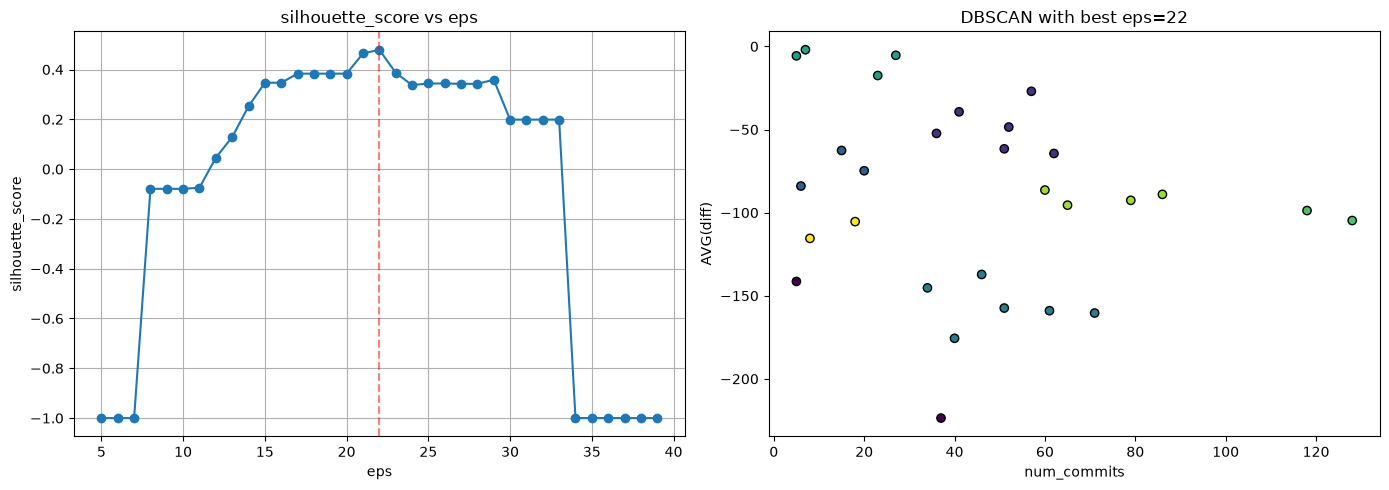


=== DBSCAN min_samples optimization ===
min_samples=1: silhouette=0.4871
min_samples=2: silhouette=0.4794
min_samples=3: silhouette=0.3596
min_samples=4: silhouette=0.1456
min_samples=5: silhouette=0.0580

Best min_samples = 1 (0.4871)


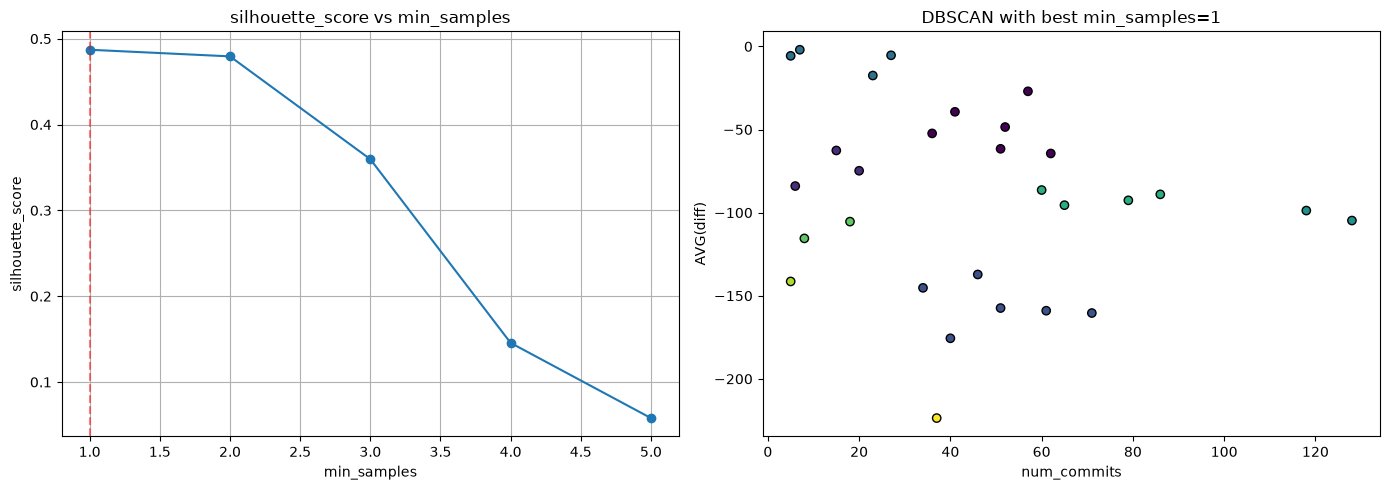


=== AgglomerativeClustering optimization ===
n_clusters=2: silhouette=0.3590
n_clusters=3: silhouette=0.3390
n_clusters=4: silhouette=0.4448
n_clusters=5: silhouette=0.4638
n_clusters=6: silhouette=0.4527
n_clusters=7: silhouette=0.4866
n_clusters=8: silhouette=0.5078
n_clusters=9: silhouette=0.4758
n_clusters=10: silhouette=0.4312
n_clusters=11: silhouette=0.4310
n_clusters=12: silhouette=0.4363
n_clusters=13: silhouette=0.4232
n_clusters=14: silhouette=0.4237

Best n_clusters = 8 (0.5078)


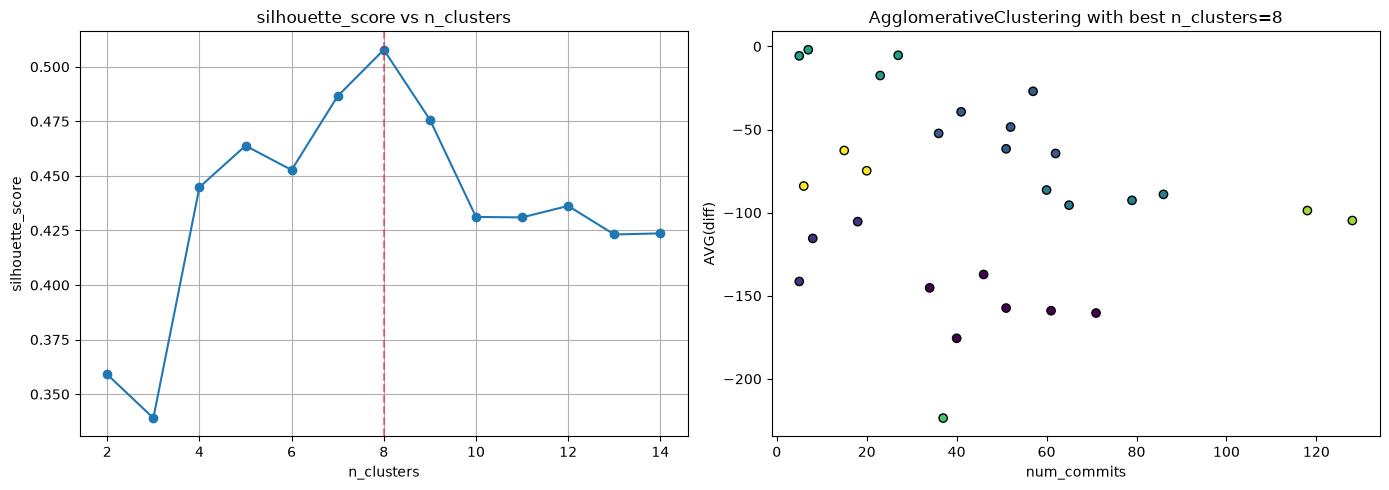

In [23]:
print('=== KMeans optimization ===')
best_k = cluster_optimize(
    KMeans,
    {'random_state': 21, 'n_init': 'auto'},
    'n_clusters',
    range(2, 15)
)

print('\n=== DBSCAN eps optimization ===')
best_eps = cluster_optimize(
    DBSCAN,
    {'min_samples': 2},
    'eps',
    range(5, 40)
)

print('\n=== DBSCAN min_samples optimization ===')
best_ms = cluster_optimize(
    DBSCAN,
    {'eps': best_eps},
    'min_samples',
    range(1, 6)
)

print('\n=== AgglomerativeClustering optimization ===')
best_k_ag = cluster_optimize(
    AgglomerativeClustering,
    {},
    'n_clusters',
    range(2, 15)
)
